In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [14]:
# creating own datast 


data = {
    "Transaction_ID": [
        "T001","T002","T003","T004","T005",
        "T006","T007","T008","T009","T010",
        "T011","T012","T013","T014","T015",
        "T016","T017","T018","T019","T020",
        "T021","T022","T023","T024","T025",
        "T026","T027","T028","T029","T030",
        "T031","T032","T033","T034","T035",
        "T036","T037","T038","T039","T040",
        "T041","T042","T043","T044","T045",
        "T046","T047","T048","T049","T050"
    ],

    "Items": [
        "Milk,Bread,Eggs",
        "Bread,Butter",
        "Milk,Bread,Butter",
        "Rice,Sugar",
        "Tea,Biscuits",
        "Milk,Eggs",
        "Bread,Eggs",
        "Milk,Bread",
        "Rice,Oil",
        "Milk,Butter,Eggs",
        "Tea,Sugar",
        "Milk,Bread,Tea",
        "Bread,Butter,Jam",
        "Milk,Cheese",
        "Eggs,Bread,Butter",
        "Rice,Dal",
        "Milk,Rice",
        "Tea,Biscuits,Sugar",
        "Milk,Bread,Eggs",
        "Butter,Jam",
        "Milk,Bread,Butter,Eggs",
        "Rice,Sugar,Tea",
        "Milk,Cheese,Butter",
        "Bread,Eggs",
        "Milk,Bread",
        "Rice,Oil,Sugar",
        "Tea,Biscuits",
        "Milk,Eggs",
        "Bread,Butter",
        "Milk,Bread,Jam",
        "Rice,Dal,Oil",
        "Milk,Cheese",
        "Bread,Eggs,Butter",
        "Tea,Sugar",
        "Milk,Bread,Eggs",
        "Rice,Oil",
        "Milk,Butter",
        "Bread,Jam",
        "Milk,Bread,Butter",
        "Tea,Biscuits",
        "Rice,Sugar",
        "Milk,Eggs",
        "Bread,Butter",
        "Milk,Bread",
        "Rice,Dal",
        "Tea,Sugar,Biscuits",
        "Milk,Bread,Eggs",
        "Butter,Cheese",
        "Milk,Bread,Butter",
        "Rice,Tea"
    ]
}

transactions = df["Items"].str.split(",").tolist()
df = pd.DataFrame(data)

df.head()

,Transaction_ID,Items
0,T001,"Milk,Bread,Eggs"
1,T002,"Bread,Butter"
2,T003,"Milk,Bread,Butter"
3,T004,"Rice,Sugar"
4,T005,"Tea,Biscuits"


In [15]:
df.shape

(50, 2)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Transaction_ID  50 non-null     str  
 1   Items           50 non-null     str  
dtypes: str(2)
memory usage: 932.0 bytes


DATA PREPROCESSING

In [17]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Biscuits,Bread,Butter,Cheese,Dal,Eggs,Jam,Milk,Oil,Rice,Sugar,Tea
0,False,True,False,False,False,True,False,True,False,False,False,False
1,False,True,True,False,False,False,False,False,False,False,False,False
2,False,True,True,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,True,False
4,True,False,False,False,False,False,False,False,False,False,False,True


In [20]:
# using apriori algorithm to find frequent itemsets with a minimum support of 0.2

frequent_itemsets = apriori(basket, min_support=0.2, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.44,frozenset({Bread})
1,0.30,frozenset({Butter})
2,0.26,frozenset({Eggs})
3,0.44,frozenset({Milk})
4,0.22,frozenset({Rice})
5,0.20,frozenset({Tea})
6,0.20,"frozenset({Butter, Bread})"
7,0.26,"frozenset({Milk, Bread})"


In [22]:
#cheakinng most frequent itemsets by support 
frequent_itemsets.sort_values(by="support", ascending=False)

,support,itemsets
0,0.44,frozenset({Bread})
3,0.44,frozenset({Milk})
1,0.30,frozenset({Butter})
2,0.26,frozenset({Eggs})
7,0.26,"frozenset({Milk, Bread})"
4,0.22,frozenset({Rice})
5,0.20,frozenset({Tea})
6,0.20,"frozenset({Butter, Bread})"


In [23]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Butter}),frozenset({Bread}),0.30,0.44,0.20,0.666667,1.515152,1.0,0.0680,1.680000,0.485714,0.370370,0.404762,0.560606
1,frozenset({Milk}),frozenset({Bread}),0.44,0.44,0.26,0.590909,1.342975,1.0,0.0664,1.368889,0.456044,0.419355,0.269481,0.590909
2,frozenset({Bread}),frozenset({Milk}),0.44,0.44,0.26,0.590909,1.342975,1.0,0.0664,1.368889,0.456044,0.419355,0.269481,0.590909


In [24]:
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']]

,antecedents,consequents,support,confidence,lift
0,frozenset({Butter}),frozenset({Bread}),0.20,0.666667,1.515152
1,frozenset({Milk}),frozenset({Bread}),0.26,0.590909,1.342975
2,frozenset({Bread}),frozenset({Milk}),0.26,0.590909,1.342975


In [25]:
rules.sort_values(by="confidence", ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Butter}),frozenset({Bread}),0.30,0.44,0.20,0.666667,1.515152,1.0,0.0680,1.680000,0.485714,0.370370,0.404762,0.560606
1,frozenset({Milk}),frozenset({Bread}),0.44,0.44,0.26,0.590909,1.342975,1.0,0.0664,1.368889,0.456044,0.419355,0.269481,0.590909
2,frozenset({Bread}),frozenset({Milk}),0.44,0.44,0.26,0.590909,1.342975,1.0,0.0664,1.368889,0.456044,0.419355,0.269481,0.590909


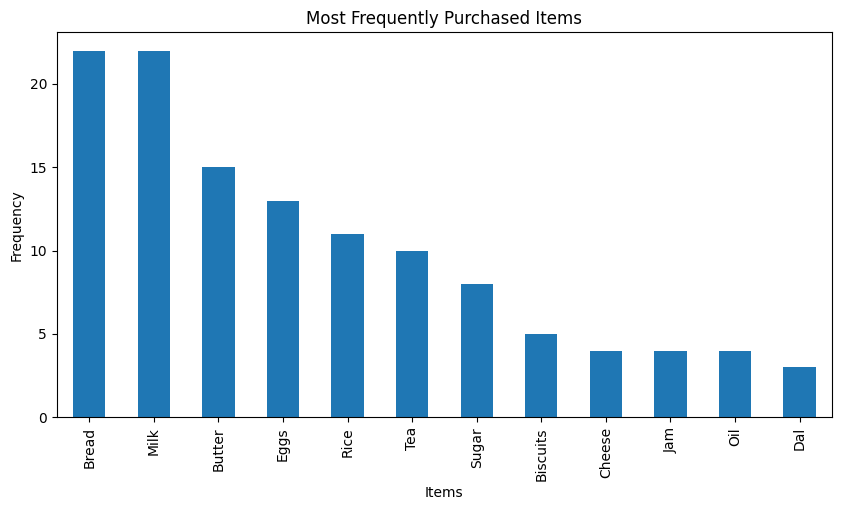

In [26]:
item_frequency = basket.sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

item_frequency.plot(kind='bar')

plt.title("Most Frequently Purchased Items")
plt.xlabel("Items")
plt.ylabel("Frequency")

plt.show()